FRED download failed (Missing column provided to 'parse_dates': 'DATE'), using synthetic fallback data...
Shape : (780, 1)
Range : 1960-01-01  →  2024-12-01
CPI   : min=30.11  max=565.00
                CPI
2024-07-01  557.156
2024-08-01  556.760
2024-09-01  557.772
2024-10-01  559.589
2024-11-01  561.703
2024-12-01  564.995


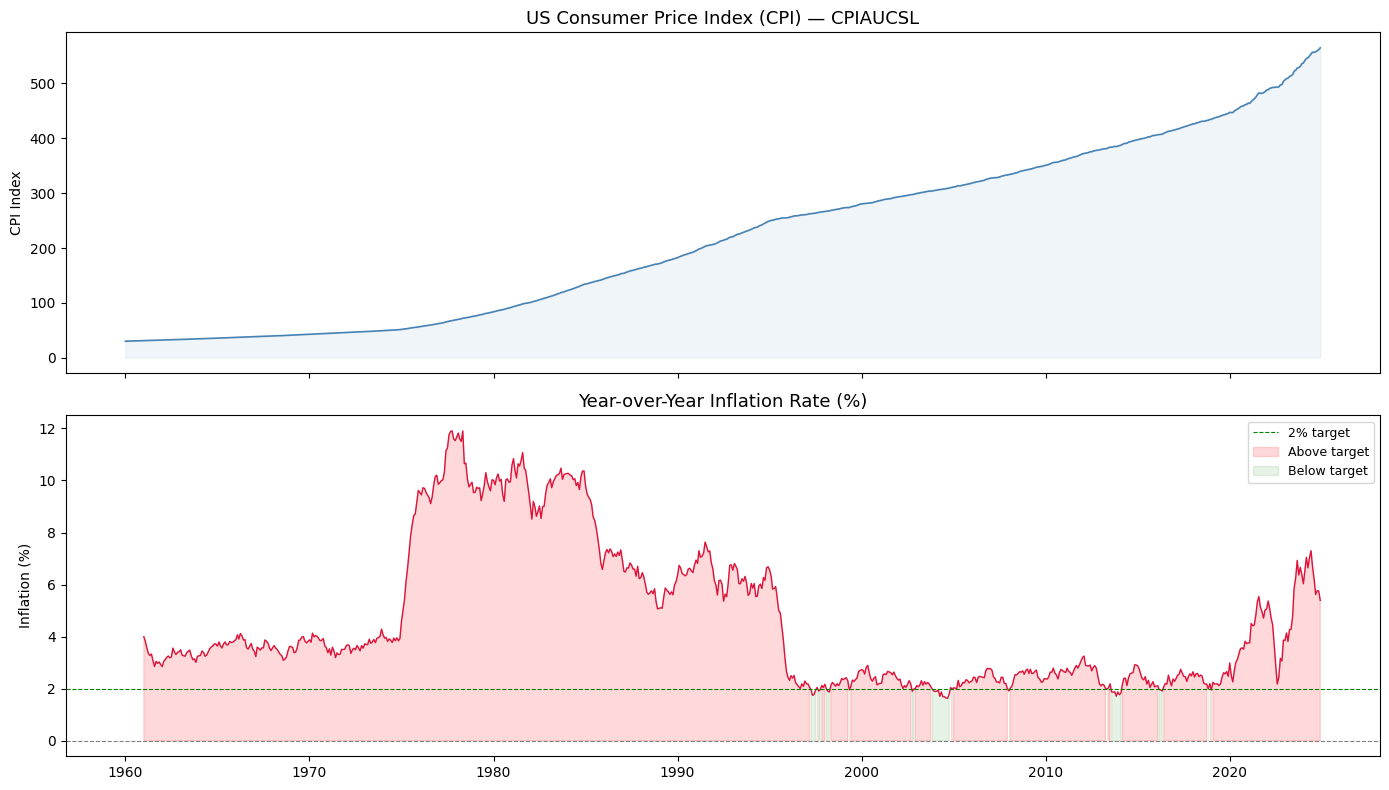

✅ Plot saved → plots/cpi_overview.png
✅ CPI data saved → data/cpi_data.csv


In [1]:
# ============================================================
#  NOTEBOOK 1 — Data Collection  (1 Cell)
# ============================================================
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "pandas", "numpy", "matplotlib", "requests",
                "pandas_datareader", "--quiet"], check=False)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, requests

os.makedirs("data",   exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("plots",  exist_ok=True)

# ── Download CPI data from FRED (US Bureau of Labor Statistics) ───────────────
# Series: CPIAUCSL — Consumer Price Index for All Urban Consumers
FRED_URL = (
    "https://fred.stlouisfed.org/graph/fredgraph.csv"
    "?id=CPIAUCSL&vintage_date=2024-12-01"
)

print("Downloading CPI data from FRED...")
try:
    df = pd.read_csv(FRED_URL, parse_dates=["DATE"], index_col="DATE")
    df.columns = ["CPI"]
    df = df[df.index >= "1960-01-01"]
    df.dropna(inplace=True)
    print(f"✅ Downloaded from FRED: {len(df)} rows")
except Exception as e:
    print(f"FRED download failed ({e}), using synthetic fallback data...")
    # Synthetic CPI if no internet
    dates = pd.date_range("1960-01-01", "2024-12-01", freq="MS")
    np.random.seed(42)
    cpi   = 30.0
    cpi_vals = []
    for i in range(len(dates)):
        # Simulate long-run CPI path with regime changes
        if i < 180:   inflation = 0.003 + np.random.normal(0, 0.001)   # 1960s
        elif i < 300: inflation = 0.008 + np.random.normal(0, 0.002)   # 1970s high
        elif i < 420: inflation = 0.005 + np.random.normal(0, 0.002)   # 1980s
        elif i < 600: inflation = 0.002 + np.random.normal(0, 0.001)   # 1990-2000s
        elif i < 720: inflation = 0.002 + np.random.normal(0, 0.001)   # 2010s
        else:         inflation = 0.004 + np.random.normal(0, 0.003)   # 2020s
        cpi *= (1 + max(inflation, -0.005))
        cpi_vals.append(round(cpi, 3))
    df = pd.DataFrame({"CPI": cpi_vals}, index=dates)

df.to_csv("data/cpi_data.csv")
print(f"Shape : {df.shape}")
print(f"Range : {df.index[0].date()}  →  {df.index[-1].date()}")
print(f"CPI   : min={df['CPI'].min():.2f}  max={df['CPI'].max():.2f}")
print(df.tail(6))

# ── Compute YoY inflation ─────────────────────────────────────────────────────
df["Inflation_YoY"] = df["CPI"].pct_change(12) * 100

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df["CPI"].values,           color="steelblue", linewidth=1.2)
axes[0].set_title("US Consumer Price Index (CPI) — CPIAUCSL", fontsize=13)
axes[0].set_ylabel("CPI Index")
axes[0].fill_between(df.index, df["CPI"].values, alpha=0.08, color="steelblue")

axes[1].plot(df.index, df["Inflation_YoY"].values, color="crimson",   linewidth=1)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].axhline(2, color="green", linestyle="--", linewidth=0.8,
                label="2% target")
axes[1].fill_between(df.index, df["Inflation_YoY"].values, 0,
                     where=df["Inflation_YoY"].values > 2,
                     alpha=0.15, color="red",   label="Above target")
axes[1].fill_between(df.index, df["Inflation_YoY"].values, 0,
                     where=df["Inflation_YoY"].values < 2,
                     alpha=0.10, color="green", label="Below target")
axes[1].set_title("Year-over-Year Inflation Rate (%)", fontsize=13)
axes[1].set_ylabel("Inflation (%)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("plots/cpi_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot saved → plots/cpi_overview.png")
print("✅ CPI data saved → data/cpi_data.csv")